In [1]:
ROOT_DIR = "/home/albert/Baikal2025/data_manager/"
import sys
sys.path.append(ROOT_DIR)
import os

import h5py
import uproot as ur
import numpy as np 
import awkward as ak 
import matplotlib.pyplot as plt
import pandas as pd

exp_root_dir = "/net/62/home/albert/Baikal/Data/exp_root_files/"
exp_h5 = "/home/albert/Baikal2025/data_manager/data/h5datasets/exp.h5"
#reco_root_dir = "/net/62/home/albert/Baikal/Data/reco_exp_root_files"

root_path_geometry = "Events/BGeomTel./BGeomTel.BGeomTel/BGeomTel.BGeomTel.fOMs/BGeomTel.BGeomTel.fOMs.fPosition"
root_pathes_data = {
    'amplitude': "Events/BEvent./BEvent.fPulses/BEvent.fPulses.fAmplitude"
    , 'time': "Events/BEvent./BEvent.fPulses/BEvent.fPulses.fTime"
    #, "Events/MCEventMask./MCEventMask.BEventMask/MCEventMask.BEventMask.fOrigins/MCEventMask.BEventMask.fOrigins.fFlag"
    , 'channel_id': "Events/BEvent./BEvent.fPulses/BEvent.fPulses.fChannelID"
}

root_files = sorted([f for f in os.listdir(exp_root_dir) if f.endswith('.root')])
root_files

['s2020_c01_r0027.root',
 's2020_c01_r0116.root',
 's2020_c01_r0188.root',
 's2020_c02_r0015.root',
 's2020_c02_r0149.root',
 's2020_c02_r0206.root',
 's2020_c02_r0357.root',
 's2020_c03_r0012.root',
 's2020_c03_r0115.root',
 's2020_c03_r0263.root',
 's2020_c03_r0417.root',
 's2020_c04_r0037.root',
 's2020_c04_r0116.root',
 's2020_c04_r0117.root',
 's2020_c05_r0035.root',
 's2020_c05_r0116.root',
 's2020_c05_r0270.root',
 's2020_c05_r0377.root',
 's2020_c06_r0032.root',
 's2020_c06_r0134.root',
 's2020_c06_r0325.root',
 's2020_c06_r0413.root',
 's2020_c07_r0041.root',
 's2020_c07_r0120.root',
 's2020_c07_r0202.root',
 's2020_c07_r0406.root']

# Look inside a root file

In [2]:
exp_root_path = f'{exp_root_dir}/{root_files[-1]}'

with ur.open(exp_root_path) as rf:
    e_channels = rf['Events/BEvent./BEvent.fPulses/BEvent.fPulses.fChannelID'].array(library='np')
    e_channels = rf['Events/BEvent./BEvent.fPulses/BEvent.fPulses.fChannelID'].array(library='np')
    root_coordinates = np.array(ak.unzip(rf[root_path_geometry].array()))
    active_clusters = [np.unique(ch // 288) for ch in e_channels]
    num_un_clusters = np.array([len(cl) for cl in active_clusters])
    
    root_data = {k: rf[p].array(library="np") for k, p in root_pathes_data.items()}
    
root_df = pd.DataFrame(root_data)
root_df['ordering'] = root_df['time'].apply(lambda x: x.argsort())
root_df

,amplitude,time,channel_id,ordering
0,"[1.7510651, 1.013125, 0.6037704, 1.2925045, 0....","[17748.322, 18316.55, 15930.041, 17852.812, 18...","[19, 23, 43, 48, 55, 60, 62, 67, 70, 70, 73, 7...","[37, 67, 56, 62, 43, 36, 19, 52, 75, 51, 55, 3..."
1,"[1.2884346, 0.98746675, 0.30666327, 1.3890383,...","[18058.625, 18709.729, 18740.188, 15805.16, 16...","[1, 4, 6, 8, 8, 10, 19, 19, 19, 22, 38, 39, 40...","[29, 52, 58, 22, 25, 79, 82, 65, 32, 35, 16, 2..."
2,"[1.0963402, 1.2968531, 1.5443537, 1.6446571, 1...","[15330.3955, 17464.902, 14697.466, 18928.682, ...","[2, 11, 13, 13, 15, 15, 15, 16, 17, 19, 21, 21...","[49, 75, 39, 17, 37, 55, 4, 42, 2, 45, 76, 48,..."
3,"[0.8967326, 1.5351387, 0.8105985, 1.2797204, 0...","[18427.625, 14274.546, 16235.675, 18552.15, 18...","[14, 15, 19, 19, 21, 38, 43, 45, 50, 52, 55, 5...","[88, 26, 30, 14, 100, 1, 42, 15, 37, 21, 63, 2..."
4,"[1.1926621, 0.42505005, 0.88100207, 0.75406414...","[18518.05, 17919.8, 17505.625, 18282.324, 1604...","[10, 12, 15, 16, 19, 21, 37, 43, 51, 55, 64, 6...","[46, 26, 77, 51, 71, 25, 81, 44, 5, 19, 63, 14..."
...,...,...,...,...
24995,"[0.3799469, 0.79690975, 1.166443, 0.25946945, ...","[18459.662, 17154.4, 14778.226, 16295.95, 1458...","[4, 15, 16, 16, 18, 18, 23, 37, 41, 43, 47, 47...","[67, 19, 58, 52, 26, 35, 4, 72, 23, 48, 71, 2,..."
24996,"[1.4974501, 0.79908186, 1.0109363, 1.2124717, ...","[14438.871, 14262.458, 18993.39, 16965.943, 14...","[9, 11, 20, 42, 45, 47, 47, 53, 55, 62, 63, 64...","[7, 24, 26, 53, 19, 58, 39, 1, 22, 0, 59, 34, ..."
24997,"[1.9696828, 0.78281647, 0.50946075, 0.63126665...","[14585.479, 15764.435, 14762.935, 15087.375, 1...","[4, 5, 11, 13, 15, 16, 16, 16, 16, 16, 16, 16,...","[32, 39, 89, 5, 70, 58, 92, 49, 6, 66, 7, 65, ..."
24998,"[0.6194233, 4.1007895, 1.9115094, 1.2773618, 2...","[14337.75, 16534.975, 16444.162, 14092.318, 16...","[9, 17, 18, 19, 19, 19, 19, 21, 21, 22, 23, 37...","[55, 76, 3, 16, 94, 67, 62, 69, 28, 57, 32, 61..."


# Look inside a corresponding h5 file

In [16]:
with h5py.File(exp_h5, 'r') as hf:
    group = hf['exp']
    print(group['raw'].keys())
    print(group[f'raw/ev_starts'].keys())
    part_name = f"part_{root_files[-1].replace('.root','')}"
    ev_starts = group[f"raw/ev_starts/{part_name}/data"][:]
    channels = group[f'raw/channels/{part_name}/data'][:]
    data = group[f'raw/data/{part_name}/data'][:]
    
    h5_data = []
    for s,e in zip(ev_starts[:-1], ev_starts[1:]):
        h5_data.append({
            'amplitude': data[s:e, 0],
            'time': data[s:e, 1],
            'z': data[s:e, 4],
            'channel_id': channels[s:e],
            'ordering': data[s:e, 1].argsort()
        })
h5_df = pd.DataFrame(h5_data)
h5_df

<KeysViewHDF5 ['channels', 'cluster_ids', 'data', 'ev_starts', 'labels', 'num_un_strings']>
<KeysViewHDF5 ['part_s2020_c01_r0027', 'part_s2020_c01_r0116', 'part_s2020_c01_r0188', 'part_s2020_c02_r0015', 'part_s2020_c02_r0149', 'part_s2020_c02_r0206', 'part_s2020_c02_r0357', 'part_s2020_c03_r0012', 'part_s2020_c03_r0115', 'part_s2020_c03_r0263', 'part_s2020_c03_r0417', 'part_s2020_c04_r0037', 'part_s2020_c04_r0116', 'part_s2020_c04_r0117', 'part_s2020_c05_r0035', 'part_s2020_c05_r0116', 'part_s2020_c05_r0270', 'part_s2020_c05_r0377', 'part_s2020_c06_r0032', 'part_s2020_c06_r0134', 'part_s2020_c06_r0325', 'part_s2020_c06_r0413', 'part_s2020_c07_r0041', 'part_s2020_c07_r0120', 'part_s2020_c07_r0202', 'part_s2020_c07_r0406']>


,amplitude,time,z,channel_id,ordering
0,"[0.6146746, 1.2792203, 1.2361441, 0.910032, 0....","[-2635.0532, -2604.2886, -2566.7495, -2484.437...","[-188.1271, -37.715527, -142.39252, 218.01637,...","[149, 267, 224, 248, 175, 147, 112, 209, 282, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,"[1.0306789, 1.2482413, 0.57932323, 1.1192464, ...","[-2628.7366, -2450.722, -2376.0735, -2243.096,...","[262.8174, 67.81689, 262.96188, -52.61198, 37....","[107, 202, 215, 86, 92, 281, 286, 227, 125, 12...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,"[1.1094215, 1.6811987, 0.6351757, 0.79642534, ...","[-2426.891, -2259.813, -2210.645, -2083.725, -...","[142.78136, 263.05167, 157.50783, -52.60139, 1...","[171, 251, 136, 50, 133, 197, 15, 151, 13, 156...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
3,"[1.3497401, 1.807633, 0.81267345, 0.1934098, 0...","[-2600.1719, -2591.6143, -2589.046, -2491.421,...","[-247.90364, 127.69021, 187.74672, 202.63368, ...","[253, 98, 102, 67, 280, 15, 127, 70, 117, 81, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,"[0.9238361, 0.7937022, 1.4641984, 1.5659907, 1...","[-2656.8394, -2607.1313, -2566.1099, -2508.967...","[187.83278, 52.39739, -157.8246, -247.77264, 9...","[174, 129, 259, 181, 240, 125, 269, 172, 21, 1...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
...,...,...,...,...,...
24995,"[0.80534965, 0.7723522, 1.5677593, 1.0431528, ...","[-2539.0393, -2459.3293, -2417.8352, -2307.079...","[263.08328, 7.4654446, 127.8803, 187.83559, -9...","[251, 54, 206, 174, 83, 107, 18, 286, 68, 162,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
24996,"[0.7259228, 0.96054155, 0.9469937, 1.2715783, ...","[-2232.44, -2204.8286, -2085.9897, -2078.6538,...","[-7.5507603, -203.03224, -142.9363, 7.788931, ...","[53, 112, 116, 234, 93, 250, 169, 11, 107, 9, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
24997,"[1.3950633, 0.8175315, 1.1814681, 0.42537397, ...","[-2164.6846, -2162.787, -2121.961, -2085.3125,...","[202.66426, 127.692924, 248.06807, -22.241343,...","[67, 98, 250, 16, 181, 152, 254, 115, 16, 177,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
24998,"[0.38567784, 0.84320444, 1.2773618, 0.5307519,...","[-2435.8374, -2378.1821, -2348.6753, -2340.930...","[187.83559, 52.854115, 22.832937, 82.5465, 217...","[174, 237, 19, 59, 284, 210, 202, 215, 86, 175...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


In [13]:
root_df.apply(lambda row: row['channel_id'][row['ordering']], axis=1)

0        [149, 267, 224, 248, 175, 147, 112, 209, 282, ...
1        [107, 202, 215, 86, 92, 281, 286, 227, 125, 12...
2        [171, 251, 136, 50, 133, 197, 15, 151, 13, 156...
3        [253, 98, 102, 67, 280, 15, 127, 70, 117, 81, ...
4        [174, 129, 259, 181, 240, 125, 269, 172, 21, 1...
                               ...                        
24995    [251, 54, 206, 174, 83, 107, 18, 286, 68, 162,...
24996    [53, 112, 116, 234, 93, 250, 169, 11, 107, 9, ...
24997    [67, 98, 250, 16, 181, 152, 254, 115, 16, 177,...
24998    [174, 237, 19, 59, 284, 210, 202, 215, 86, 175...
24999    [211, 209, 1, 220, 15, 96, 13, 129, 22, 73, 13...
Length: 25000, dtype: object

In [19]:
z_root_0 = root_df['channel_id'].iloc[0][root_df['ordering'].iloc[0]]
z_h5_0 = h5_df['z'].iloc[0]

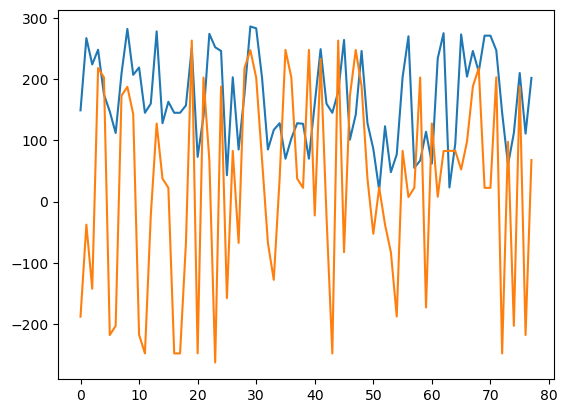

In [21]:
plt.plot(z_root_0)
plt.plot(z_h5_0)